# A tunable multifrequency honeycomb lattice

In this tutorial, we will show how to compute lattice potential originating from the incoherent addtion of laser beams. We are going to take as example the tunable-honeycomb lattice presented in [[Kosch2022]](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.043083). In their paper, the authors present a multi-frequency lattice made of the 2-by-2 interference of 3 laser beams intersecting at $120^\circ$ from one another. Each laser beam has two frequency component, and shares one component with only one other beam. This leads to the emergence of 3 different 1D-lattices. These 1D lattices incoherently add up, and it is the relative position of each lattice's peak (determined by the relative phase between each beam) that determines the lattice geometry. Let's now implement it.

In [7]:
from optilat.builder import OptiLat, Beam
from bloch_schrodinger.potential import Potential, create_parameter
import numpy as np
import matplotlib.pyplot as plt


lamb = 0.83 # Laser wavelength
laser_angles = [np.pi/2 + np.pi * 2 / 3 * i for i in range(3)]*2 # 120 deg lasers
coherence = [0,0,1,2,1,2]

# We are going to use two relative phase the last one not being necessary because of the global phase invariance of the lattice
phi2 = create_parameter("phi2", np.linspace(0,np.pi*2, 25))  
phi3 = create_parameter("phi3", np.linspace(0,np.pi*2, 25))

beams = []

for i in range(6):
    ang = laser_angles[i]
    
    if i == 1:
        phase = np.exp(1j*phi2)
    elif i == 2:
        phase = np.exp(1j*phi3)
    else:
        phase = 1
    beam = Beam(
        amplitude = phase * 1,
        wavelength=lamb, 
        direction=[np.cos(ang), np.sin(ang), 0],
        polar = [0, 1]
    )
    beams+=[beam]

lattice = OptiLat()
lattice.add_beam(beams, coherence)

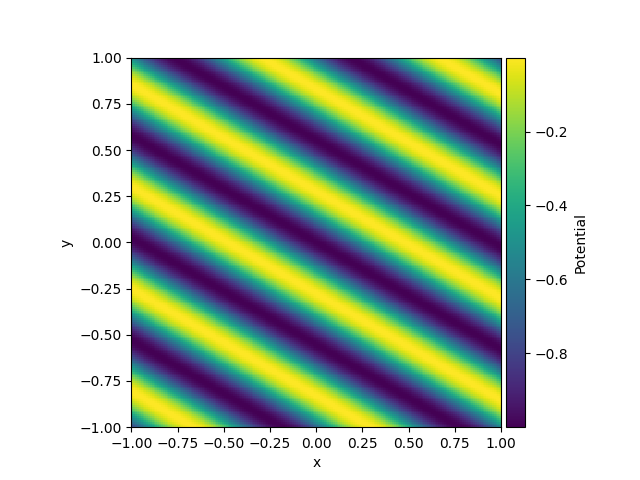

In [8]:
# We create first an empty potential object, over which we are going to compute the effect of the AC Stark effect
honeycomb = Potential(
    [[2,0], [0,2]],
    resolution=(200,200)
)

Field = lattice.compute_fields(x = honeycomb.x, y = honeycomb.y).squeeze() # We squeeze Fields to remove the size-1 Field dimension
# We are going to define every constant in arbitrary units here
E1 = 1 # The amplitude of a single beam, in arbitrary units
alpha_s = 1 # Scalar polarizability

V = -1/4 * E1**2 * (abs(Field)**2).sum(["component"]) * alpha_s

honeycomb.set(V)

%matplotlib widget
honeycomb.plot()
plt.show()

If we do not sum over the "field" dimension, we can see the three 1D lattice created, and the relative phase dependance of their peak position. Now, the total potential is actually proportional to the sum of the intensities. 

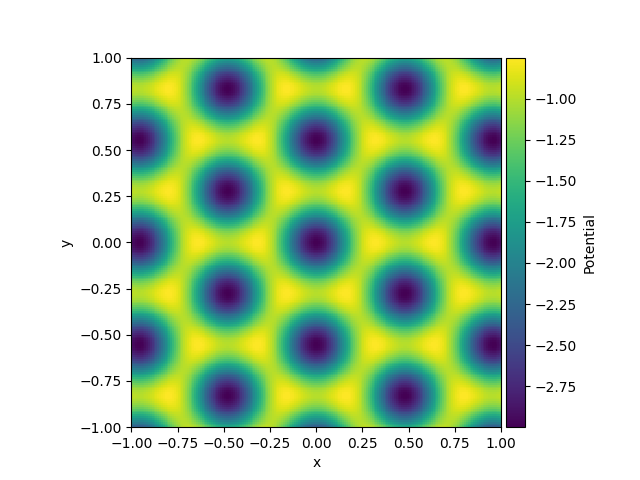

In [9]:
V = -1/4 * E1**2 * (abs(Field)**2).sum(["component", "field"]) * alpha_s
honeycomb.clear()
honeycomb.set(V)

honeycomb.plot()
plt.show()